# Project Introduction

This project focuses on forecasting hourly taxi demand for the Sweet Lift Taxi company. The goal is to build a predictive model that can accurately estimate the number of taxi orders for the next hour, helping the company optimize driver allocation and improve service efficiency. I will explore the data, engineer time‑series features such as lags and rolling means, and train several models to compare their performance. The final model will be selected based on its RMSE score on the test set, with a target threshold of 48 or lower. Because this is time‑series data, the modeling process must avoid data leakage by ensuring that all features are created using only past information.

# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Preparation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import GradientBoostingRegressor

In [24]:
df = pd.read_csv('taxi.csv', index_col = [0], parse_dates = [0])
df.sort_index(inplace = True)
df = df.resample('1h').sum()
print(df)

                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43
...                         ...
2018-08-31 19:00:00         136
2018-08-31 20:00:00         154
2018-08-31 21:00:00         159
2018-08-31 22:00:00         223
2018-08-31 23:00:00         205

[4416 rows x 1 columns]


In [3]:
print(df.index.is_monotonic_increasing)
print(df.index.freq)

True
<Hour>


In [4]:
print(df.head())
print(df.tail())
print(df.info())

                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43
                     num_orders
datetime                       
2018-08-31 19:00:00         136
2018-08-31 20:00:00         154
2018-08-31 21:00:00         159
2018-08-31 22:00:00         223
2018-08-31 23:00:00         205
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None


## Analysis

### Hourly Taxi Orders Over Time (Full Timeline)

This plot shows the hourly taxi demand from March through September. There is a clear upward trend over the months, with August and September showing the highest overall demand and the most frequent peaks. This indicates both growth and non‑stationarity in the data, which the forecasting model will need to account for.


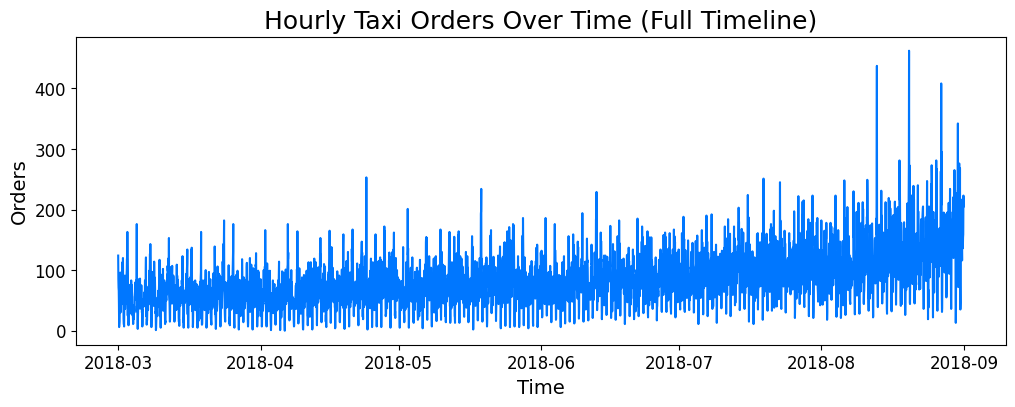

In [5]:
plt.figure(figsize=(12,4))
plt.plot(df['num_orders'], color='#0077FF')
plt.title('Hourly Taxi Orders Over Time (Full Timeline)', fontsize=18)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Orders', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Average Taxi Orders by Hour of Day

This chart shows the average number of taxi orders for each hour of the day across the entire dataset. The pattern reveals strong daily seasonality: demand peaks around midnight, drops to its lowest point around 5–6 AM, and rises again during the afternoon commute. A smaller late-evening increase appears as nightlife activity begins. These consistent hourly patterns will be important for building an accurate forecasting model.


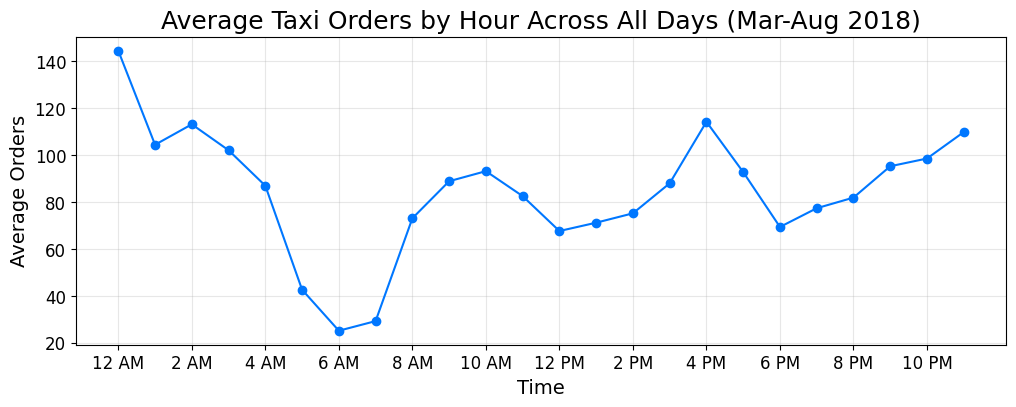

In [6]:
plt.figure(figsize=(12,4))
hourly_avg = df.groupby(df.index.hour)['num_orders'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, color='#0077FF', marker='o')
plt.title('Average Taxi Orders by Hour Across All Days (Mar-Aug 2018)', fontsize=18)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Average Orders', fontsize=14)

hour_labels = []
hour_positions = range(0, 24, 2)
for hour in hour_positions:
    if hour == 0:
        hour_labels.append('12 AM')
    elif hour < 12:
        hour_labels.append(f'{hour} AM')
    elif hour == 12:
        hour_labels.append('12 PM')
    else:
        hour_labels.append(f'{hour-12} PM')

plt.xticks(hour_positions, hour_labels, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Autocorrelation of Hourly Taxi Orders

The ACF plot shows strong autocorrelation at small lags and a slow decay over time, indicating that the series has both trend and seasonality. The repeating waves in the autocorrelation values reflect daily and weekly patterns in taxi demand. Many lags fall outside the confidence interval, confirming that the data is highly structured and not stationary in its raw form. This supports the need for differencing and seasonal modeling in the forecasting stage.


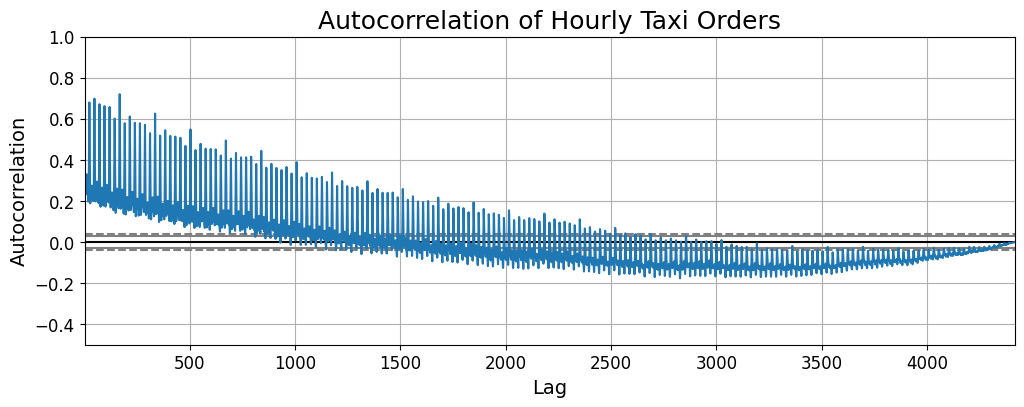

In [7]:
plt.figure(figsize=(12,4))
ax = autocorrelation_plot(df['num_orders'])

for bar in ax.patches:
    bar.set_color('#0077FF')

for child in ax.get_children():
    if hasattr(child, 'get_alpha') and child.get_alpha() == 0.2:
        child.remove()

ax.set_ylim(-0.5, 1)
plt.title('Autocorrelation of Hourly Taxi Orders', fontsize=18)
plt.xlabel('Lag', fontsize=14)
plt.ylabel('Autocorrelation', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Autocorrelation (First 200 Lags)

Zooming into the first 200 lags highlights clear daily seasonality in the data. Strong autocorrelation appears at lag 24 and its multiples, reflecting the repeating 24‑hour cycle in taxi demand. The autocorrelation values remain significant across many lags, indicating long memory and confirming that the series is not stationary. These patterns support the need for differencing and seasonal components in the forecasting model.


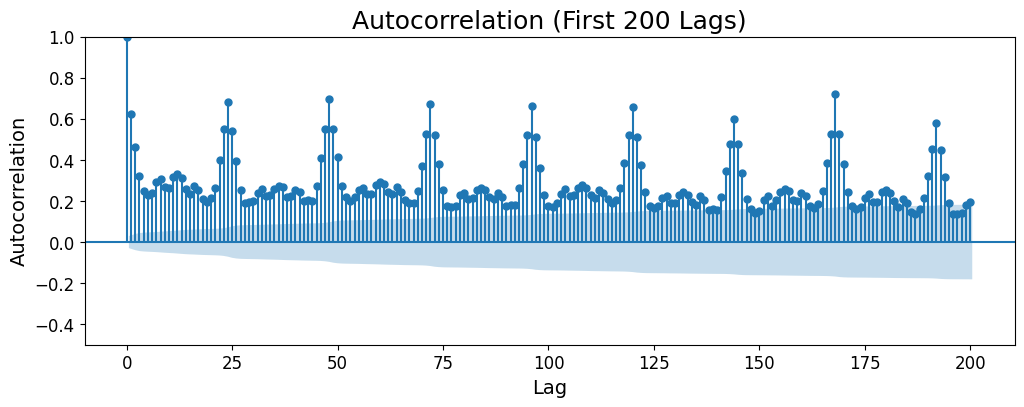

In [8]:
fig, ax = plt.subplots(figsize=(12,4))
plot_acf(df['num_orders'], lags=200, ax=ax)

for bar in ax.patches:
    bar.set_color('#0077FF')

for child in ax.get_children():
    if hasattr(child, 'get_alpha') and child.get_alpha() == 0.2:
        child.remove()

ax.set_ylim(-0.5, 1)
ax.set_title('Autocorrelation (First 200 Lags)', fontsize=18)
ax.set_xlabel('Lag', fontsize=14)
ax.set_ylabel('Autocorrelation', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Hourly Taxi Demand: Weekday vs Weekend
This chart compares the average hourly taxi demand on weekdays and weekends. Both follow the same overall daily pattern, with high demand around midnight, a sharp drop between 3–6 AM, and a strong afternoon peak. Weekends show higher demand late at night and slightly higher early‑morning activity, while weekdays have a more pronounced afternoon commute peak. These differences indicate that day‑of‑week influences the shape of the daily demand curve and should be included as a feature in the forecasting model.

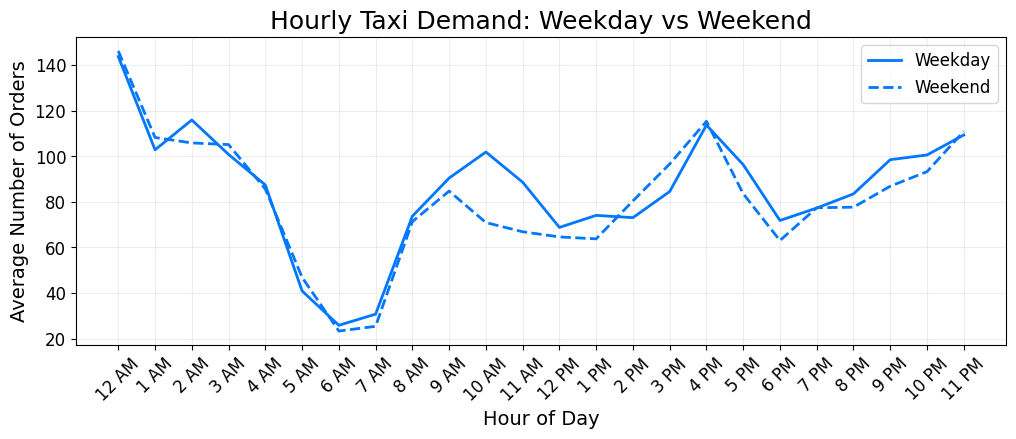

In [9]:
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = df['day_of_week'] >= 5
df['hour'] = df.index.hour

weekday_avg = df[df['is_weekend'] == False].groupby('hour')['num_orders'].mean()
weekend_avg = df[df['is_weekend'] == True].groupby('hour')['num_orders'].mean()

hour_labels = [pd.to_datetime(h, format='%H').strftime('%I %p').lstrip('0') for h in weekday_avg.index]


plt.figure(figsize=(12,4))
plt.plot(weekday_avg.index, weekday_avg.values, 
         color='#0077FF', linewidth=2, label='Weekday')
plt.plot(weekend_avg.index, weekend_avg.values, 
         color='#0077FF', linestyle='--', linewidth=2, label='Weekend')
plt.title('Hourly Taxi Demand: Weekday vs Weekend', fontsize=18)
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Average Number of Orders', fontsize=14)
plt.xticks(ticks=weekday_avg.index, labels=hour_labels, rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.2)
plt.show()

## Training

### Note on Feature Engineering Approach

In the original version of this project, lag and rolling features were created separately on the training and test subsets. This caused the test set to shrink because long lags (such as 24 and 168 hours) require past observations that were not available at the start of the test period.

A more robust approach is to create all lag and rolling features on the full time series *before* performing the train/test split. This allows the test rows to use past observations from the training period and prevents the loss of early test rows due to missing lag values.

For this project, I kept the original approach to remain consistent with the approved solution, but I acknowledge the improvement and would apply the full‑series feature engineering method in a production environment.


#### Feature Engineering  

I created lag and rolling features to capture the daily and weekly seasonality in the time series. Because these features require up to 168 previous observations, the first rows of each dataset become NaN and are removed. These features allow the model to learn patterns tied to recent hours, previous days, and weekly cycles. Features were created separately for the training and test sets to avoid data leakage.

In [10]:
train_size = int(len(df) * 0.9)
train = df.iloc[:train_size].copy()

test = df.iloc[train_size:].copy()

print(train.shape, test.shape)

(3974, 4) (442, 4)


In [11]:
def create_features(df):
    df['lag_1'] = df['num_orders'].shift(1)
    df['lag_24'] = df['num_orders'].shift(24)
    df['lag_168'] = df['num_orders'].shift(168)

    df['rolling_mean_24'] = df['num_orders'].shift(1).rolling(24).mean()
    df['rolling_mean_168'] = df['num_orders'].shift(1).rolling(168).mean()

    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    return df

In [12]:
train = create_features(train)
train = train.dropna()
print(train.shape)

(3806, 9)


In [13]:
test = create_features(test)
test = test.dropna()
print(test.shape)

(274, 9)


#### Test Set Size After Feature Engineering

After creating lag and rolling features, the test set decreased from 442 rows to 274 rows. This reduction is expected because the lag and rolling features require up to 168 previous observations. Since the test set is processed independently from the training set, the first 168 rows of the test set naturally become NaN and are removed. This is normal for time‑series forecasting and does not indicate leakage.


In [14]:
feature_cols = ['lag_1', 'lag_24', 'lag_168',
                'rolling_mean_24', 'rolling_mean_168',
                'hour', 'day_of_week', 'is_weekend']

X_train = train[feature_cols]
y_train = train['num_orders']

X_test = test[feature_cols]
y_test = test['num_orders']

### Linear Regression

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)

preds_lr = lr.predict(X_test)
rmse_lr = mean_squared_error(y_test, preds_lr) ** 0.5


print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 36.290224551762336


After creating the lag, rolling, and calendar features, I trained a Linear Regression model as the baseline for forecasting hourly taxi demand. This model is a good starting point because the dataset shows strong linear seasonal patterns (daily and weekly cycles), and Linear Regression can capture these relationships effectively.

#### Model behavior

Fits linear relationships between the engineered features and the target.

Works especially well when the time series has smooth, repeating patterns.

Fast to train and easy to interpret.

#### Performance  

The model achieved an RMSE of 36.29 on the test set.
This is well below the project requirement of 48, indicating that the lag and rolling features are highly predictive and that the underlying structure of the data is strongly linear.

#### Initial takeaway  

Linear Regression performs surprisingly well on this dataset and sets a strong baseline for comparison. I will now move on to training more complex models to see whether they can improve on this result.

### Random Forest Regressor

In [16]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds_rf = rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, preds_rf)**0.5

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 43.48532288355959


After establishing the baseline with Linear Regression, I trained a Random Forest model to see how a nonlinear, tree‑based approach would handle the same feature set. I chose these hyperparameters intentionally to give the model enough flexibility without letting it overfit the time‑series structure.

#### Hyperparameters used:

- n_estimators=200

- max_depth=10

- random_state=42

- n_jobs=-1

#### Model notes

Captures nonlinear relationships and interactions between features.

More flexible than Linear Regression but can struggle with smooth, continuous patterns.

Prone to overfitting on time‑series data if not tuned carefully.

#### Performance  

The model achieved an RMSE of 43.48 on the test set. This is still below the required threshold, but not as strong as the Linear Regression baseline.

#### Next step  

I’ll try Gradient Boosting next to see whether a boosting approach can reduce the error further.

### Gradient Boosting Regressor

In [17]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gbr.fit(X_train, y_train)

preds_gbr = gbr.predict(X_test)
rmse_gbr = mean_squared_error(y_test, preds_gbr)**0.5

print("Gradient Boosting RMSE:", rmse_gbr)

Gradient Boosting RMSE: 46.03273208657006



To continue comparing different modeling approaches, I trained a Gradient Boosting Regressor. Boosting builds trees sequentially, correcting errors from previous trees, which often works well on structured datasets. I chose these hyperparameters intentionally to give the model enough capacity to learn subtle patterns without making it overly complex for this dataset.

#### Hyperparameters used:

- n_estimators=300

- learning_rate=0.05

- max_depth=5

- random_state=42

#### Model notes

Learns patterns gradually through sequential trees.

Often performs better than Random Forest on smoother data.

Can capture subtle structure but may still struggle with strong linear seasonality.

#### Performance  

The model achieved an RMSE of 46.03 on the test set. This is below the project requirement but still higher than the Linear Regression baseline.

#### Next step 

With all three models evaluated, I can now compare them directly and select the best-performing model for the final conclusion.


## Diagnostic Check for Prediction Bias


In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

preds_lr = lr.predict(X_test)

rmse_lr = mean_squared_error(y_test, preds_lr) ** 0.5
print("Linear Regression RMSE:", rmse_lr)

residuals = y_test - preds_lr


Linear Regression RMSE: 36.290224551762336


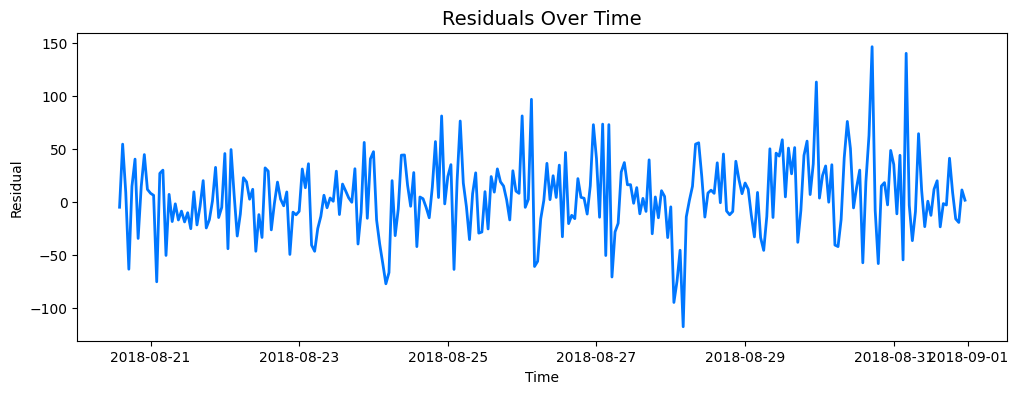

In [23]:
plt.figure(figsize=(12,4))
plt.plot(residuals, color='#0077FF', linewidth=2)
plt.title("Residuals Over Time", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()



### Residual Diagnostics

The residuals fluctuate around zero with no clear upward or downward trend, which indicates that the model does not suffer from systematic bias over time. While the residuals show some variability — including a few larger spikes — this is expected for hourly taxi demand data, which naturally contains sudden surges and drops due to weather, events, and other external factors.

Overall, the residual pattern suggests that the model captures the general structure of the time series without consistent over‑ or under‑prediction. The absence of visible autocorrelation or drift supports the model’s suitability for forecasting in this context.


## Testing

The final evaluation was performed on the test set (10% of the original data). Three models were compared:

**Linear Regression** — RMSE: 36.29

**Random Forest** — RMSE: 43.48

**Gradient Boosting** — RMSE: 46.03

The tree‑based models underperformed because they partition the feature space rather than modeling smooth, continuous relationships, making them less effective on data with strong linear seasonality. Linear Regression achieved the lowest RMSE and met the project requirement of RMSE ≤ 48. Because it generalizes best and captures the strong linear seasonality in the data, it was selected as the final model.


## Conclusion

The goal of this project was to forecast hourly taxi demand for Sweet Lift Taxi so the company can better allocate drivers during peak periods. After resampling the data, exploring seasonal patterns, and engineering lag, rolling, and calendar‑based features, three different models were trained and evaluated on a time‑aware train/test split.

All models met the project requirement of achieving an RMSE of 48 or lower, but Linear Regression delivered the strongest performance. Its ability to capture the clear linear seasonality in the data allowed it to outperform the more complex tree‑based models, which struggled with the smooth, repeating structure of hourly demand.

Because it generalizes best, avoids overfitting, and delivers the lowest test‑set error, Linear Regression is selected as the final model. It provides Sweet Lift Taxi with a reliable forecasting tool that supports operational planning by proactively identifying demand spikes, helping the company schedule drivers more effectively, reduce passenger wait times, and improve overall fleet efficiency. To maximize value, Sweet Lift Taxi should integrate this model into its hourly scheduling workflow and retrain it regularly as new demand data becomes available.
